# Tutorial 3: Aligning spatial transcriptomics data and spatial epigenomics data of mouse coronal brain slices 

## Data Preparation

Please download the required data files from the provided link:
[Download here](https://pan.baidu.com/s/17K1cmxOPmhSvV6dG6gnafw?pwd=sjbx)

- `H3K27me3_RNA.h5ad`
- `H3K4me3_PEAK.h5ad`

After downloading, place both files into the `datasets` folder located in the same directory as this notebook.

The folder structure should be organized as follows:

```
project_root/
│
├── datasets/
│   └── MBCS2/
│       ├── H3K27me3_RNA.h5ad
│       └── H3K4me3_PEAK.h5ad
│
├── Tutorial3_Aligning_spatial_transcriptomics_data_and_spatial_epigenomics_data_of_mouse_coronal_brain_slices.ipynb
│
└── SpaMOMA/
```

## import packages

In [1]:
import os
import scanpy as sc
import anndata
from SpaMOMA.SpaMOMA import SpaMOMA

## Specify Slice Metadata

In [2]:
save_directory = "./SpaMOMA_output/MBCS2/"  
spamoma = SpaMOMA(save_dir=save_directory)
spamoma.add_slice(
    sample_id="H3K27me3_RNA",  
    raw_data_path="./datasets/MBCS2/H3K27me3_RNA.h5ad",  
    feature="rna"  
)
spamoma.add_slice(
    sample_id="H3K4me3_PEAK", 
    raw_data_path="./datasets/MBCS2/H3K4me3_PEAK.h5ad", 
    feature="peak"  
)
spamoma.set_reference('H3K4me3_PEAK')



In [3]:
print(f"aligning {[sid for sid in spamoma.input_slice_dict.keys() if sid != spamoma.reference_sample_id]} to {spamoma.reference_sample_id}")

aligning ['H3K27me3_RNA'] to H3K4me3_PEAK


## Data Preprocessing

preprocessing rna features...


------Calculating spatial graph...


The graph contains 68264 edges, 9752 cells.
7.0000 neighbors per cell on average.
Size of Input:  (9752, 3000)


2026-02-19 16:17:17.147232: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-02-19 16:17:17.155966: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled



100%|██████████| 500/500 [04:01<00:00,  2.07it/s]

preprocessing peak features...


------Calculating spatial graph...


The graph contains 66836 edges, 9548 cells.
7.0000 neighbors per cell on average.
Size of Input:  (9548, 100)


2026-02-19 16:21:43.918071: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...



100%|██████████| 500/500 [01:06<00:00,  7.55it/s]

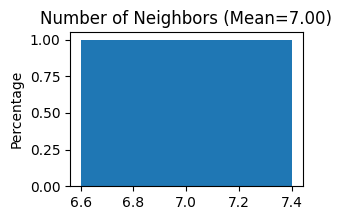

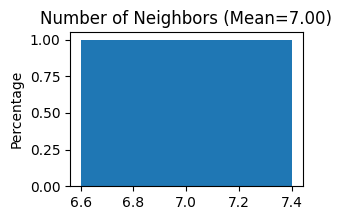

In [4]:
spamoma.preprocess_input_slices()

## Generate Spatial Pattern Images

generating spatial pattern image... gaussian_sigma:1.0, interpolation_method:linear, max_distance_ratio"1.2


saving image...


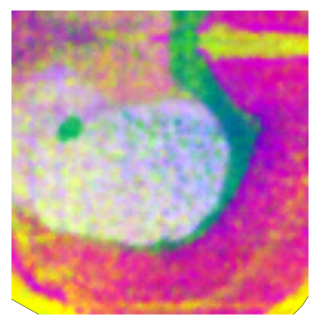

Img for H3K27me3_RNA is saved to ./SpaMOMA_output/MBCS2/H3K27me3_RNA/RGB.png
generating spatial pattern image... gaussian_sigma:1.0, interpolation_method:linear, max_distance_ratio"1.2


saving image...


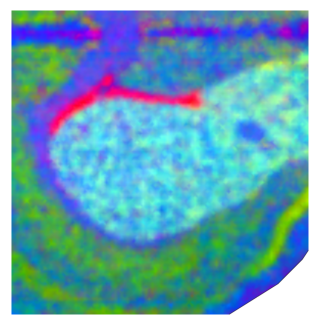

Img for H3K4me3_PEAK is saved to ./SpaMOMA_output/MBCS2/H3K4me3_PEAK/RGB.png


In [5]:
spamoma.generate_imgs()

In [6]:
spamoma.input_slice_dict

{'H3K27me3_RNA': {'sample_id': 'H3K27me3_RNA',
  'raw_data_path': './datasets/MBCS2/H3K27me3_RNA.h5ad',
  'feature': 'rna',
  'pseudo_color_key': 'pca',
  'processed_data': AnnData object with n_obs × n_vars = 9752 × 3000
      obs: 'nCount_Spatial', 'nFeature_Spatial', 'nCount_SCT', 'nFeature_SCT', 'nCount_H3K27me3', 'nFeature_H3K27me3', 'nCount_peaks', 'nFeature_peaks', 'RNA_clusters', 'H3K27me3_clusters', 'spot_x', 'spot_y', 'img_x', 'img_y', 'batch', 'my_pixel_x', 'my_pixel_y'
      var: 'name', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
      uns: 'hvg', 'log1p', 'spatial_neighbors', 'moranI'
      obsm: 'X_lsi', 'X_pca', 'X_umap', 'spatial', 'pca'
      obsp: 'spatial_connectivities', 'spatial_distances',
  'SPI_path': './SpaMOMA_output/MBCS2/H3K27me3_RNA/RGB.png'},
 'H3K4me3_PEAK': {'sample_id': 'H3K4me3_PEAK',
  'raw_data_path': './datasets/MBCS2/H3K4me3_PEAK.h5ad',
  'feature': 'peak',
  'pseudo_color_key': 'pca',
  'processed_data': AnnD

## Model Training

In [7]:
spamoma.train(coarse_epochs=1000,fine_epochs=1000, coarse_checkpoint_save_step=100,fine_checkpoint_save_step=100,parallel_mode=True,coarse_gpu=2,fine_gpu=2)

start coarse adaptation...
start fine adaptation...


fine adaptation done!
coarse adaptation done!


## Slice Alignment

In [8]:
spamoma.align_slices()

aligned H3K4me3_PEAK adata is saved to: ./SpaMOMA_output/MBCS2//alignment_output/H3K4me3_PEAK.h5ad


****************** aligning H3K27me3_RNA to H3K4me3_PEAK ..... ******************
start coarse alignment...
match params: {'model_key': 'roma', 'match_threshold': 0.999, 'extract_max_keypoints': 4096, 'force_resize': True, 'image_height': 560, 'image_width': 560, 'choice_geometry_type': 'Homography'}
Loading Roma model: ./SpaMOMA_output/MBCS2//coarse_model/adapted_model_epoch_500.pth


current Roma instance ID: 140651558015088
preprocessing is already resized
Force resize to 560x560


coarse alignment done!
start fine alignment...
Loading Roma model: ./SpaMOMA_output/MBCS2//fine_model/adapted_model_epoch_500.pth


current Roma instance ID: 140651558007664
preprocessing is already resized
Force resize to 560x560


aligned H3K27me3_RNA adata is saved to: ./SpaMOMA_output/MBCS2//alignment_output/H3K27me3_RNA.h5ad
fine alignment done!


## Visualize Alignment Results

In [9]:
adata1=spamoma.read_aligned_data('H3K4me3_PEAK')
adata2=spamoma.read_aligned_data('H3K27me3_RNA')

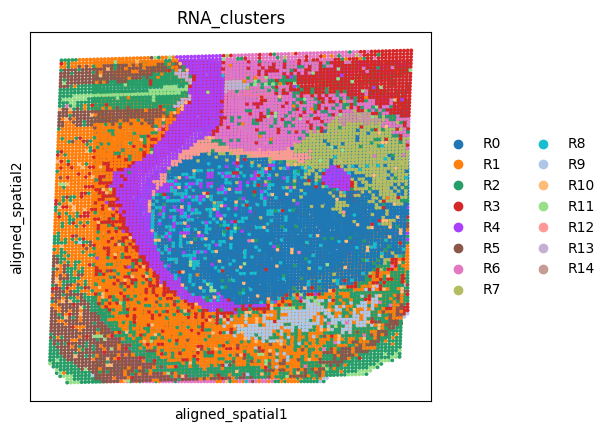

In [10]:
adata_concat=anndata.concat([adata1,adata2])
sc.pl.spatial(adata_concat,color='RNA_clusters',spot_size=25,basis='aligned_spatial')

## Omics-to-omics translation

### transfer omics from adata2 to adata1, and transfer omics from adata1 to adata2

In [ ]:
adata1_complemented=spamoma.SpaMOMA_translate(adata1,adata2,save_path='./SpaMOMA_output/MBCS2/translation_output/H3K4me3_PEAK_complemented.h5ad')
adata2_complemented=spamoma.SpaMOMA_translate(adata2,adata1,save_path='./SpaMOMA_output/MBCS2/translation_output/H3K27me3_RNA_complemented.h5ad')

Translating omics-data from adata_src to adata_target...
Translating omics-data from adata_src to adata_target...


## Identify spatial domains for each translated slice1

************ running SpatialGlue ***************
processing peak
processing rna



100%|██████████| 1600/1600 [00:44<00:00, 35.93it/s]

Model training finished!



************ running MISO ***************
CUDA is available. GPU: NVIDIA A100 80GB PCIe


Training network for modality 1:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Succeed to find 18 clusters at resolution 0.469


Succeed to find 18 clusters at resolution 0.609
fitting ...



  |======================================================================| 100%

got consensus_matrix


got consensus_labels


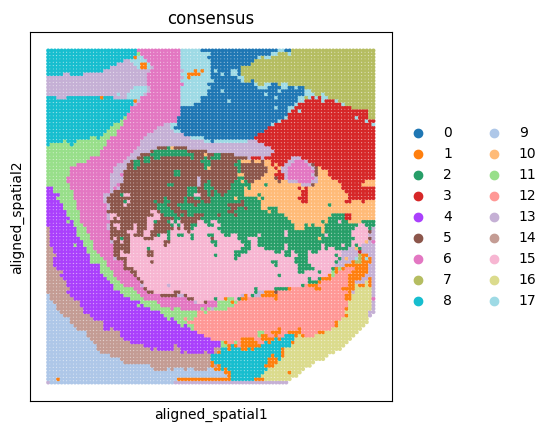

In [12]:
adata=spamoma.SpaMOMA_clustering(adata1,'peak',adata1_complemented,'rna',data_type='Spatial-epigenome-transcriptome',n_domains=18,
                                 method_list=['PRESENT','MISO','SpatialGlue'],cluster_types=['leiden','louvain','mclust'],add_key='consensus')
sc.pl.spatial(adata,color='consensus',basis='aligned_spatial',spot_size=25)

In [13]:
cluster_save_dir=f"{save_directory}/cluster_result_single_slice/"
if not os.path.exists(cluster_save_dir):
    os.makedirs(cluster_save_dir,exist_ok=True)
adata.write(f'{cluster_save_dir}/H3K4me3_PEAK.h5ad')

### Identify spatial domains for each translated slice2

************ running SpatialGlue ***************
processing rna


processing peak



100%|██████████| 1600/1600 [00:36<00:00, 44.15it/s]

Model training finished!



************ running MISO ***************
CUDA is available. GPU: NVIDIA A100 80GB PCIe


...

Succeed to find 18 clusters at resolution 0.562


Succeed to find 18 clusters at resolution 1.500
fitting ...



  |======================================================================| 100%

got consensus_matrix


got consensus_labels


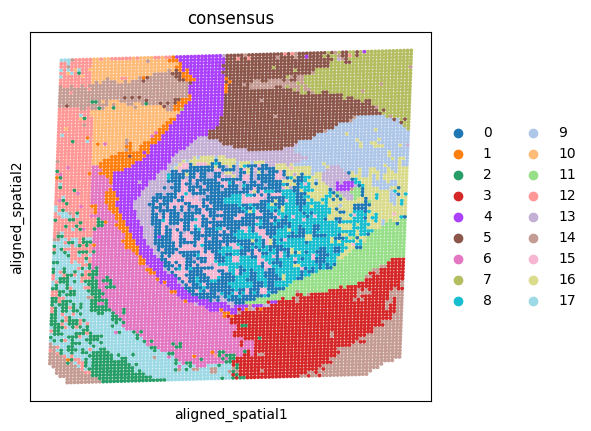

In [14]:
adata=spamoma.SpaMOMA_clustering(adata2,'rna',adata2_complemented,'peak',data_type='Spatial-epigenome-transcriptome',n_domains=18,
                                 method_list=['PRESENT','MISO','SpatialGlue'],cluster_types=['leiden','louvain','mclust'],add_key='consensus')
sc.pl.spatial(adata,color='consensus',basis='aligned_spatial',spot_size=25)

In [15]:
cluster_save_dir=f"{save_directory}/cluster_result_single_slice/"
if not os.path.exists(cluster_save_dir):
    os.makedirs(cluster_save_dir,exist_ok=True)
adata.write(f'{cluster_save_dir}/H3K27me3_RNA.h5ad')

## Jointly identify spatial domains across the two translated slices

In [16]:
multiple_slices_dict={
    'H3K4me3_PEAK':{
        'peak':adata1.copy(),
        'rna':adata1_complemented.copy()
    },
    'H3K27me3_RNA':{
        'peak':adata2_complemented.copy(),
        'rna':adata2.copy()
    }
}

reference_modality_dict={
    'H3K4me3_PEAK':'peak',
    'H3K27me3_RNA':'rna'
}

Loading data and parameters...
Input data has been loaded


First-stage trains basic model:  22%|██▏       | 22/100 [07:44<27:26, 21.11s/it, NLL_loss=0.986, BNN_loss=7.29, MSE_loss=0.733, IOA_loss=0.283, ES counter=20, ES patience=20]


Early stop the first-stage training process


Second-stage trains BC model:  10%|█         | 10/100 [10:27<1:34:08, 62.76s/it, IBA_loss=1.04, IBP_loss=0.113, DISC_loss=0.698, GEN_loss=-0.698, ES counter=10, ES patience=10]


Early stop the second-stage training process
Succeed to find 18 clusters at resolution 0.562

========== Processing batch: H3K4me3_PEAK ==========

========== Processing batch: H3K27me3_RNA ==========


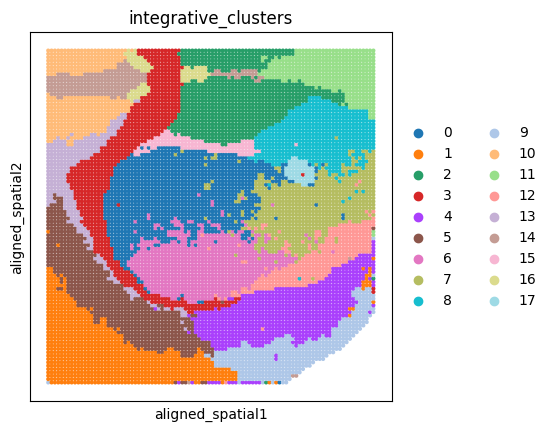

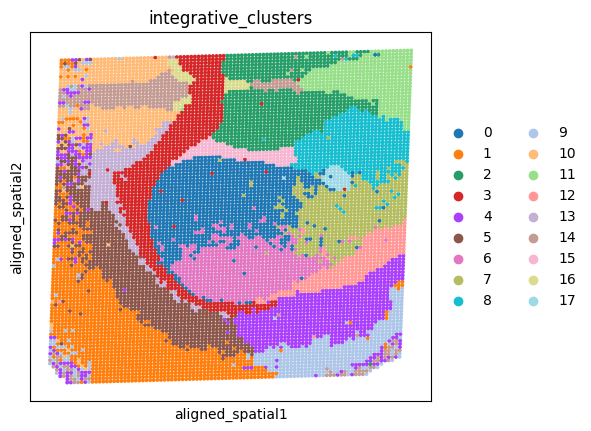

In [ ]:
adata_dict=spamoma.SpaMOMA_clustering_multiple_slices(multiple_slices_dict,reference_modality_dict,batch_key='batch',n_domains=18)
sc.pl.spatial(adata_dict['H3K4me3_PEAK'],color='integrative_clusters',basis='aligned_spatial',spot_size=25)
sc.pl.spatial(adata_dict['H3K27me3_RNA'],color='integrative_clusters',basis='aligned_spatial',spot_size=25)

In [ ]:
cluster_save_dir=f"{save_directory}/cluster_result_multiple_slices/"
if not os.path.exists(cluster_save_dir):
    os.makedirs(cluster_save_dir,exist_ok=True)
adata_dict['H3K4me3_PEAK'].write(f'{cluster_save_dir}/H3K4me3_PEAK.h5ad')
adata_dict['H3K27me3_RNA'].write(f'{cluster_save_dir}/H3K27me3_RNA.h5ad')